# Notebook 01 — SQL Data Profiling
**Project**: Hospital Readmission Prediction  
**Purpose**: Load the raw dataset into SQLite, run SQL profiling queries, and document data quality findings before any Python-based analysis.

**Why SQL first?** In real analytics roles, you'll query data warehouses (Snowflake, BigQuery, Redshift) before pulling to Python. This notebook mirrors that workflow.

---
**Prerequisites**: Download `diabetic_data.csv` from Kaggle and place in `../data/`  
https://www.kaggle.com/datasets/brandao/diabetes

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded ✓')

Matplotlib is building the font cache; this may take a moment.


Libraries loaded ✓


## 1. Load Data into SQLite
We load the CSV into an in-memory SQLite database so we can run SQL queries directly from the notebook.

In [2]:
# Load CSV
df_raw = pd.read_csv('../data/diabetic_data.csv', na_values='?')
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO


In [3]:
# Create SQLite connection and load DataFrame
conn = sqlite3.connect(':memory:')
df_raw.to_sql('diabetic_data', conn, if_exists='replace', index=False)

def sql(query):
    """Helper: run SQL query and return a DataFrame."""
    return pd.read_sql_query(query, conn)

print('SQLite DB ready ✓')

SQLite DB ready ✓


## 2. Row Count & Dataset Overview

In [4]:
overview = sql("""
SELECT
    COUNT(*)                        AS total_encounters,
    COUNT(DISTINCT patient_nbr)     AS distinct_patients,
    ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT patient_nbr), 2) AS avg_encounters_per_patient
FROM diabetic_data
""")
display(overview)

# Key observation: some patients appear multiple times — we'll deduplicate in modeling

,total_encounters,distinct_patients,avg_encounters_per_patient
0,101766,71518,1.42


## 3. Missing Values Analysis

In [5]:
# Count missing values per column (pandas, since SQLite NULL check is verbose)
missing = df_raw.isnull().sum().reset_index()
missing.columns = ['column', 'missing_count']
missing['missing_pct'] = (missing['missing_count'] / len(df_raw) * 100).round(2)
missing = missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print('Columns with missing values:')
display(missing)

# weight is ~97% missing — drop it
# payer_code is ~40% missing — drop or impute with 'Unknown'
# medical_specialty is ~49% missing — group unknowns into 'Other'

Columns with missing values:


,column,missing_count,missing_pct
5,weight,98569,96.86
22,max_glu_serum,96420,94.75
23,A1Cresult,84748,83.28
11,medical_specialty,49949,49.08
10,payer_code,40256,39.56
2,race,2273,2.23
20,diag_3,1423,1.40
19,diag_2,358,0.35
18,diag_1,21,0.02


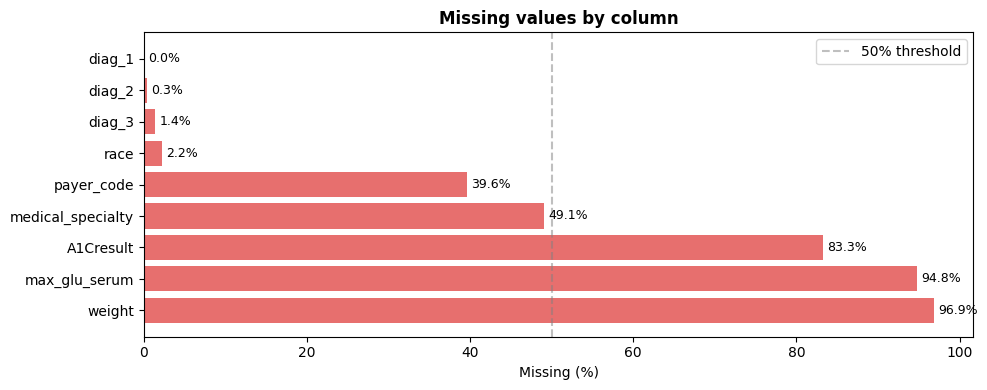

Saved: reports/01_missing_values.png


In [6]:
# Visualise missingness
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing['column'], missing['missing_pct'], color='#E24B4A', alpha=0.8)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing values by column', fontweight='bold')
for bar, pct in zip(bars, missing['missing_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.axvline(50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/01_missing_values.png')

## 4. Target Variable Distribution

In [7]:
target_dist = sql("""
SELECT
    readmitted,
    COUNT(*) AS count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM diabetic_data), 2) AS pct
FROM diabetic_data
GROUP BY readmitted
ORDER BY count DESC
""")
display(target_dist)

# Key finding: <30 day readmissions are a minority class — will need SMOTE

,readmitted,count,pct
0,NO,54864,53.91
1,>30,35545,34.93
2,<30,11357,11.16


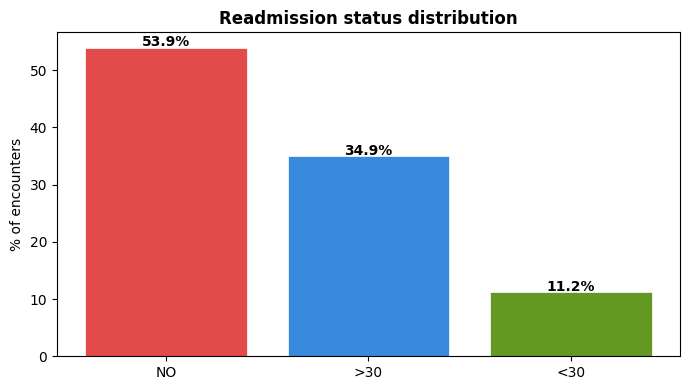

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#E24B4A', '#378ADD', '#639922']
bars = ax.bar(target_dist['readmitted'], target_dist['pct'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_ylabel('% of encounters')
ax.set_title('Readmission status distribution', fontweight='bold')
for bar, pct in zip(bars, target_dist['pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/02_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Readmission Rate by Key Segments

In [9]:
# By age group
age_readmission = sql("""
SELECT
    age AS age_group,
    COUNT(*) AS total,
    SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) AS readmitted_30,
    ROUND(SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS readmission_rate_pct
FROM diabetic_data
GROUP BY age
ORDER BY age
""")
display(age_readmission)

,age_group,total,readmitted_30,readmission_rate_pct
0,[0-10),161,3,1.86
1,[10-20),691,40,5.79
2,[20-30),1657,236,14.24
3,[30-40),3775,424,11.23
4,[40-50),9685,1027,10.60
5,[50-60),17256,1668,9.67
6,[60-70),22483,2502,11.13
7,[70-80),26068,3069,11.77
8,[80-90),17197,2078,12.08
9,[90-100),2793,310,11.10


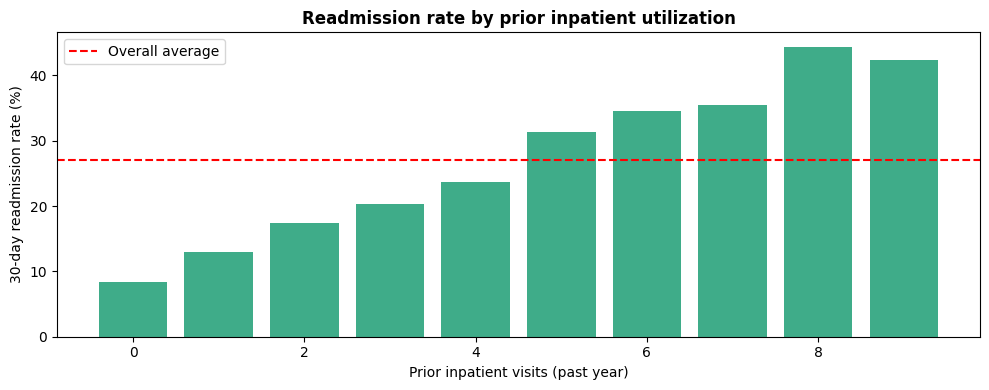


>>> KEY FINDING: Readmission rate rises sharply with prior inpatient visits.
    This will likely be the top feature in the model.


In [10]:
# By prior inpatient visits
inpatient_readmission = sql("""
SELECT
    number_inpatient AS prior_inpatient_visits,
    COUNT(*) AS total,
    ROUND(SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS readmission_rate_pct
FROM diabetic_data
GROUP BY number_inpatient
HAVING COUNT(*) > 100
ORDER BY number_inpatient
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(inpatient_readmission['prior_inpatient_visits'],
       inpatient_readmission['readmission_rate_pct'],
       color='#1D9E75', alpha=0.85)
ax.set_xlabel('Prior inpatient visits (past year)')
ax.set_ylabel('30-day readmission rate (%)')
ax.set_title('Readmission rate by prior inpatient utilization', fontweight='bold')
ax.axhline(inpatient_readmission['readmission_rate_pct'].mean(),
           color='red', linestyle='--', label='Overall average')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/03_readmission_by_inpatient.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n>>> KEY FINDING: Readmission rate rises sharply with prior inpatient visits.')
print('    This will likely be the top feature in the model.')

In [11]:
# By discharge disposition
discharge_readmission = sql("""
SELECT
    discharge_disposition_id,
    COUNT(*) AS total,
    ROUND(SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS readmission_rate_pct
FROM diabetic_data
GROUP BY discharge_disposition_id
HAVING COUNT(*) > 500
ORDER BY total DESC
""")
display(discharge_readmission)

# Cross-reference disposition IDs with IDs_mapping.csv from Kaggle for labels

,discharge_disposition_id,total,readmission_rate_pct
0,1,60234,9.30
1,3,13954,14.66
2,6,12902,12.70
3,18,3691,12.44
4,2,2128,16.07
5,22,1993,27.70
6,11,1642,0.00
7,5,1184,20.86
8,25,989,9.30
9,4,815,12.76


In [12]:
# Save deduplicated table for downstream notebooks
first_encounter_query = """
SELECT *
FROM diabetic_data
WHERE encounter_id IN (
    SELECT MIN(encounter_id)
    FROM diabetic_data
    GROUP BY patient_nbr
)
"""
df_first = sql(first_encounter_query)
df_first.to_csv('../data/diabetic_first_encounter.csv', index=False)
print(f'Deduplicated dataset saved: {df_first.shape[0]:,} rows')
print(f'Removed {len(df_raw) - len(df_first):,} duplicate encounters')

Deduplicated dataset saved: 71,518 rows
Removed 30,248 duplicate encounters


## 6. SQL Profiling Summary

| Finding | Detail |
|---|---|
| Total encounters | ~101,766 |
| Distinct patients | ~71,518 |
| 30-day readmission rate | ~11.2% |
| Missing: `weight` | ~97% → **drop** |
| Missing: `payer_code` | ~40% → impute 'Unknown' |
| Missing: `medical_specialty` | ~49% → group as 'Other' |
| Key predictor (SQL) | `number_inpatient` — strong monotonic relationship with readmission |
| Deduplication | Keep first encounter per patient to avoid data leakage |

**Next**: `02_eda.ipynb` — deep exploratory analysis with visualizations.